In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Install libraries
# ════════════════════════════════════════════════════════════════
!pip install pulp networkx scipy folium pyproj numpy pandas -q
print('✓ Libraries ready')

✓ Libraries ready


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — Configuration
# ════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd, warnings
warnings.filterwarnings('ignore')

BASE           = '/content/drive/MyDrive/Projects/SEM 6'
FLOOD_CSV      = f'{BASE}/all_cells_depth.csv'      # HEC-RAS output (UTM 43N)
MANHOLE_CSV    = f'{BASE}/Gurgoan_Manholes_Cleaned.csv'
BUILDING_CSV   = f'{BASE}/Gurgaon_Buildings_Acc_to_LandUse.csv'

# ── Budget ────────────────────────────────────────────────────
Budget         = float(input("Enter total budget (INR): ") or 1200000)
COST_MODULE    = 30000
K_SENSORS      = int(Budget // COST_MODULE)
print(f"  → K = {K_SENSORS} sensors")

# ── Spatial ──────────────────────────────────────────────────
DEG_TO_M           = 111000
MAX_PIPE_DIST_M    = 80
MAX_PIPE_DEG       = MAX_PIPE_DIST_M / DEG_TO_M
K_NEIGHBOURS       = 8
UPSTREAM_REACH_M   = 600
UPSTREAM_DEG       = UPSTREAM_REACH_M / DEG_TO_M
BUILDING_RAD_M     = 350
BUILDING_DEG       = BUILDING_RAD_M / DEG_TO_M
MIN_SENSOR_SEP_M   = 750
MIN_SENSOR_SEP_DEG = MIN_SENSOR_SEP_M / DEG_TO_M
BASE_RADIUS_M      = 80

# ── Flood / Noise model ──────────────────────────────────────
# sigma: std-dev of sensor Gaussian noise (metres of water depth)
# A cheap ultrasonic sensor has ~0.05-0.10 m noise; quality ones ~0.01 m
NOISE_SIGMA        = 0.05    # metres  ← TUNE THIS
DEPTH_THRESHOLD    = 0.10    # minimum depth (m) to declare flooding
N_MONTE_CARLO      = 500     # MC samples for expected detection probability

# Weight: how much flood-depth importance boosts node weight
# (0 = ignore flood data; 1 = fully driven by depth)
FLOOD_WEIGHT_ALPHA = 0.40

# ── DEA threshold ────────────────────────────────────────────
DEA_THRESHOLD      = 0.35
LOW_SINK_THRESH    = 0.70

# ── GMDA known critical flood points ────────────────────────
GMDA_CRITICAL = [
    ('Hero Honda Chowk',         28.4595, 77.0266, 1.00),
    ('Iffco Chowk underpass',    28.4726, 77.0738, 1.00),
    ('Signature Tower Chowk',    28.4691, 77.0801, 1.00),
    ('Rajiv Chowk Sohna Road',   28.4156, 77.0399, 1.00),
    ('Shanker Chowk',            28.4748, 77.0855, 1.00),
    ('Sikanderpur Chowk',        28.4801, 77.0934, 1.00),
    ('Galleria Market Chowk',    28.4756, 77.0978, 1.00),
    ('Leg-I Sikanderpur origin', 28.4823, 77.0834, 1.00),
    ('Leg-II Sector42 origin',   28.4589, 77.0823, 1.00),
    ('Leg-III Ghata origin',     28.3823, 77.0456, 1.00),
    ('Najafgarh Drain outfall',  28.5234, 76.9823, 1.00),
    ('HUDA City Centre',         28.4593, 77.0723, 0.90),
    ('Vatika Chowk',             28.3967, 77.0580, 0.90),
    ('Subhash Chowk',            28.4253, 77.0438, 0.90),
    ('Bakhtawar Chowk',          28.4526, 77.0637, 0.90),
    ('MDI Chowk',                28.4674, 77.0302, 0.90),
    ('Sector 34 Badshahpur',     28.4389, 77.0501, 0.90),
    ('Wazirabad Chowk',          28.4934, 77.1012, 0.85),
    ('Mayfield Garden Chowk',    28.4234, 77.0712, 0.85),
    ('Medanta Hospital Gate 2',  28.4456, 77.0423, 0.85),
    ('Gold Souk Chowk',          28.4889, 77.0967, 0.75),
    ('Kanahai Chowk Sec43/44',   28.4478, 77.0712, 0.75),
    ('Fortis Hospital road',     28.4601, 77.0745, 0.80),
    ('Old Delhi Rd Sirhole',     28.4823, 77.0201, 0.70),
    ('Sector 27 near Bandh',     28.4634, 77.0567, 0.70),
    ('Rezangla Chowk',           28.4345, 77.0123, 0.70),
]
df_gmda = pd.DataFrame(GMDA_CRITICAL, columns=['name','lat','lon','priority'])

BUILDING_WEIGHT = {
    'hospital':1.00,'train_station':0.95,'transportation':0.90,
    'college':0.88,'university':0.88,'supermarket':0.85,
    'commercial':0.80,'office':0.78,'industrial':0.75,'warehouse':0.72,
    'retail':0.65,'hotel':0.62,'stadium':0.60,'school':0.58,
    'kindergarten':0.55,'public':0.55,'apartments':0.50,'residential':0.45,
    'house':0.42,'detached':0.40,'semidetached_house':0.38,'bungalow':0.35,
    'terrace':0.35,'service':0.32,'temple':0.30,'military':0.25,
    'construction':0.20,'hangar':0.18,'grandstand':0.15,'farm':0.12,
    'garage':0.10,'guardhouse':0.10,'shed':0.08,'park':0.05,
    'recreation_ground':0.05,'farmland':0.04,'grass':0.03,'scrub':0.03,
    'forest':0.02,'nature_reserve':0.02,'unclassified':0.00,'roof':0.00,'bunker':0.00,
}
TRAFFIC_WEIGHT = {
    'motorway':1.00,'motorway_link':0.90,'trunk':0.88,'trunk_link':0.80,
    'primary':0.75,'primary_link':0.65,'secondary':0.55,'secondary_link':0.48,
    'tertiary':0.38,'tertiary_link':0.32,'residential':0.25,'living_street':0.20,
    'unclassified':0.15,'service':0.12,
}
SEWER_FCLASS = {
    'motorway','motorway_link','trunk','trunk_link','primary','primary_link',
    'secondary','secondary_link','tertiary','tertiary_link',
    'residential','living_street','unclassified','service',
}
print('✓ Config done')

Enter total budget (INR): 1200000
  → K = 40 sensors
✓ Config done


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — Load Flood CSV + CRS Conversion (UTM 43N → WGS84)
# ════════════════════════════════════════════════════════════════
import os
from pyproj import Transformer
from scipy.spatial import cKDTree
from scipy.stats import norm as sp_norm

# Fallback path
if not os.path.exists(FLOOD_CSV):
    FLOOD_CSV = 'all_cells_depth.csv'
    print(f'ℹ Using local: {FLOOD_CSV}')

print(f'📂 Loading flood data: {FLOOD_CSV}')
df_flood_raw = pd.read_csv(FLOOD_CSV)
df_flood_raw = df_flood_raw.dropna(subset=['x','y','elevation'])
df_flood_raw['elevation'] = pd.to_numeric(df_flood_raw['elevation'], errors='coerce')
df_flood_raw['max_depth'] = pd.to_numeric(df_flood_raw['max_depth'],  errors='coerce').fillna(0.0)
df_flood_raw = df_flood_raw.dropna(subset=['elevation'])
print(f'  Valid flood cells: {len(df_flood_raw):,}')

# ── CRS Conversion: EPSG:32643 → EPSG:4326 ────────────────────
# Coords in CSV are UTM Zone 43N (x ~ 690k–710k, y ~ 3128k–3158k)
transformer = Transformer.from_crs('EPSG:32643', 'EPSG:4326', always_xy=True)
flood_lons, flood_lats = transformer.transform(
    df_flood_raw['x'].values,
    df_flood_raw['y'].values
)
df_flood_raw['lat'] = flood_lats
df_flood_raw['lon'] = flood_lons

print(f'  Lat range : {flood_lats.min():.4f}° – {flood_lats.max():.4f}°')
print(f'  Lon range : {flood_lons.min():.4f}° – {flood_lons.max():.4f}°')
print(f'  Depth range: {df_flood_raw["max_depth"].min():.4f} – {df_flood_raw["max_depth"].max():.4f} m')

# ── Keep only HEC-RAS cells inside Gurugram bounding box ──────
# (removes edge artefacts and cells outside study area)
BB = dict(lat_min=28.30, lat_max=28.60, lon_min=76.85, lon_max=77.20)
df_flood = df_flood_raw[
    (df_flood_raw['lat'] >= BB['lat_min']) & (df_flood_raw['lat'] <= BB['lat_max']) &
    (df_flood_raw['lon'] >= BB['lon_min']) & (df_flood_raw['lon'] <= BB['lon_max'])
].copy().reset_index(drop=True)
print(f'  Cells inside Gurugram bbox: {len(df_flood):,}')

# Build a KD-tree on the flood cells (WGS84) for spatial join later
flood_coords_wgs = df_flood[['lon','lat']].values
flood_tree       = cKDTree(flood_coords_wgs)

print('✓ Flood data loaded and CRS converted')

📂 Loading flood data: /content/drive/MyDrive/Projects/SEM 6/all_cells_depth.csv
  Valid flood cells: 67,845
  Lat range : 28.2707° – 28.5380°
  Lon range : 76.8232° – 77.1438°
  Depth range: 0.0000 – 0.0000 m
  Cells inside Gurugram bbox: 61,524
✓ Flood data loaded and CRS converted


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — Gaussian Noise Model
#
#  Each HEC-RAS cell has a "true" max flood depth d_i.
#  A sensor at or near that cell measures:
#      d̂_i = d_i + ε_i,   ε_i ~ N(0, σ²)
#
#  Key quantities derived:
#  1. noisy_depth_mean  : E[d̂_i]        = d_i   (unbiased)
#  2. noisy_depth_std   : Std[d̂_i]      = σ
#  3. snr               : d_i / σ        (signal-to-noise)
#  4. detection_prob    : P(d̂_i > thresh) = Φ((d_i - thresh)/σ)
#
#  Interpretation for sensor placement:
#  • High depth + high SNR  → easy to detect; one sensor covers the area.
#  • High depth + LOW SNR   → flood is real but sensor may miss it → HIGH priority.
#  • Low depth              → marginal flooding; lower priority unless GMDA critical.
#
#  The "noise_priority" score rewards high depth AND low detection probability:
#      noise_priority_i = depth_i × (1 - detection_prob_i)
#  This is 0 for non-flooded cells, and peaks where flooding is severe but hard to detect.
# ════════════════════════════════════════════════════════════════
import numpy as np
from scipy.stats import norm as sp_norm

rng = np.random.default_rng(seed=42)

depths_true = df_flood['max_depth'].values.astype(np.float64)

# ── Monte Carlo: simulate N_MONTE_CARLO sensor readings ─────
# Shape: (N_MONTE_CARLO, n_cells)
print(f'Running Monte Carlo noise simulation ({N_MONTE_CARLO} realisations)...')
noise_samples = rng.normal(loc=0.0, scale=NOISE_SIGMA,
                            size=(N_MONTE_CARLO, len(depths_true)))
noisy_depths  = depths_true[np.newaxis, :] + noise_samples   # (MC, cells)
noisy_depths  = np.maximum(noisy_depths, 0.0)                # depth ≥ 0 (physical)

# ── Analytical expressions (exact, no sampling needed) ─────
snr             = depths_true / (NOISE_SIGMA + 1e-10)
detection_prob  = sp_norm.cdf((depths_true - DEPTH_THRESHOLD) / NOISE_SIGMA)
noise_priority  = depths_true * (1.0 - detection_prob)

# Normalise to [0,1]
def norm01(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-12)

df_flood['snr']            = snr
df_flood['detection_prob'] = detection_prob
df_flood['noise_priority'] = noise_priority
df_flood['noise_priority_n'] = norm01(noise_priority)
df_flood['depth_n']          = norm01(depths_true)

flooded_cells = (df_flood['max_depth'] > DEPTH_THRESHOLD).sum()
risky_cells   = (df_flood['noise_priority_n'] > 0.5).sum()
print(f'  σ (noise std-dev)         : {NOISE_SIGMA:.3f} m')
print(f'  Detection threshold       : {DEPTH_THRESHOLD:.3f} m')
print(f'  Flooded cells (>thresh)   : {flooded_cells:,}')
print(f'  High noise-priority cells : {risky_cells:,}')
print(f'  Mean detection prob       : {detection_prob[depths_true>DEPTH_THRESHOLD].mean():.3f}')
print(f'  MC noisy depth mean       : {noisy_depths.mean():.4f} m (should ≈ true mean)')
print(f'  MC noisy depth std        : {noisy_depths.std():.4f} m (should ≈ σ = {NOISE_SIGMA})')
print('✓ Noise model complete')

Running Monte Carlo noise simulation (500 realisations)...
  σ (noise std-dev)         : 0.050 m
  Detection threshold       : 0.100 m
  Flooded cells (>thresh)   : 0
  High noise-priority cells : 35,266
  Mean detection prob       : nan
  MC noisy depth mean       : 0.0199 m (should ≈ true mean)
  MC noisy depth std        : 0.0292 m (should ≈ σ = 0.05)
✓ Noise model complete


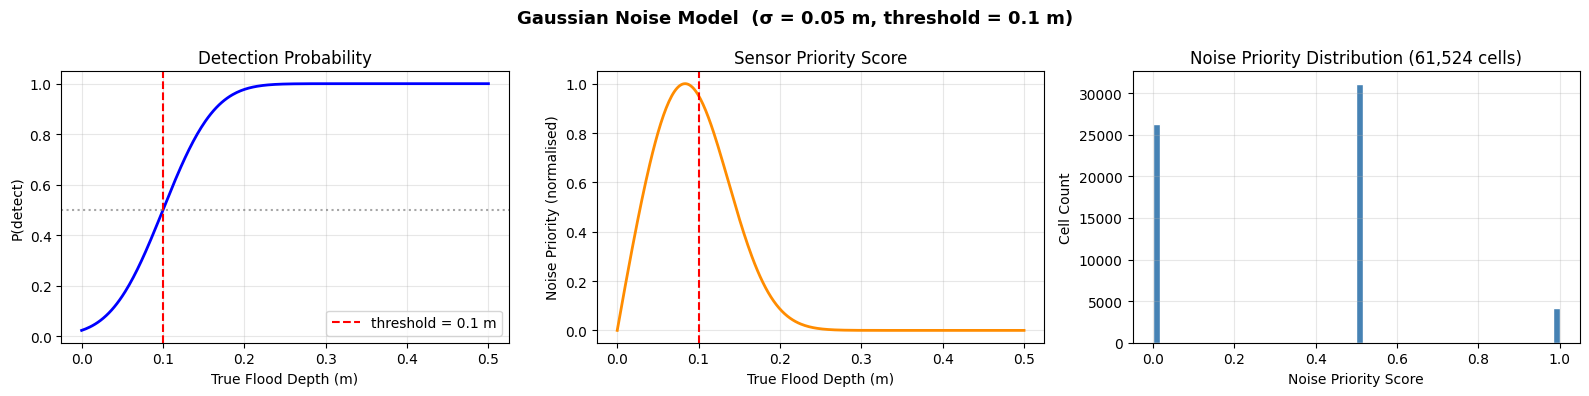

✓ Noise model plots saved to /content/noise_model.png


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — Visualise the Noise Model
# ════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

d_range  = np.linspace(0, max(0.5, depths_true.max()), 300)
snr_line = d_range / NOISE_SIGMA
pd_line  = sp_norm.cdf((d_range - DEPTH_THRESHOLD) / NOISE_SIGMA)
np_line  = d_range * (1 - pd_line)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Gaussian Noise Model  (σ = {NOISE_SIGMA} m, threshold = {DEPTH_THRESHOLD} m)',
             fontsize=13, fontweight='bold')

# Panel 1: Detection probability vs true depth
axes[0].plot(d_range, pd_line, 'b-', linewidth=2)
axes[0].axvline(DEPTH_THRESHOLD, color='red', linestyle='--', label=f'threshold = {DEPTH_THRESHOLD} m')
axes[0].axhline(0.5, color='gray', linestyle=':', alpha=0.7)
axes[0].set_xlabel('True Flood Depth (m)'); axes[0].set_ylabel('P(detect)')
axes[0].set_title('Detection Probability'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Panel 2: Noise priority score vs true depth
axes[1].plot(d_range, np_line / (np_line.max()+1e-12), 'darkorange', linewidth=2)
axes[1].axvline(DEPTH_THRESHOLD, color='red', linestyle='--')
axes[1].set_xlabel('True Flood Depth (m)'); axes[1].set_ylabel('Noise Priority (normalised)')
axes[1].set_title('Sensor Priority Score'); axes[1].grid(alpha=0.3)

# Panel 3: Distribution of noise-priority scores across all cells
axes[2].hist(df_flood['noise_priority_n'], bins=60, color='steelblue', edgecolor='white', lw=0.3)
axes[2].set_xlabel('Noise Priority Score'); axes[2].set_ylabel('Cell Count')
axes[2].set_title(f'Noise Priority Distribution ({len(df_flood):,} cells)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/noise_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Noise model plots saved to /content/noise_model.png')

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 7 — Load Manhole / Candidate Nodes + Spatial Join to Flood Data
# ════════════════════════════════════════════════════════════════
import os

if not os.path.exists(MANHOLE_CSV):
    raise FileNotFoundError(f'Manhole CSV not found: {MANHOLE_CSV}')

print('Loading manholes...')
df_mh = pd.read_csv(MANHOLE_CSV, low_memory=False)
for col in ['Elev1','x_coord','y_coord']:
    df_mh[col] = pd.to_numeric(df_mh[col], errors='coerce')
df_mh = df_mh.dropna(subset=['Elev1','x_coord','y_coord'])
df_mh = df_mh[df_mh['fclass'].isin(SEWER_FCLASS)]
df_mh = df_mh.drop_duplicates(subset=['x_coord','y_coord'], keep='first')
df_mh['point_type'] = 'manhole'
print(f'  Manhole nodes: {len(df_mh):,}')

# ── Road intermediate points ──────────────────────────────────
print('Generating road intermediate points...')
SPACING_DEG = 100 / DEG_TO_M
road_pts = []
road_groups = df_mh.groupby('osm_id') if 'osm_id' in df_mh.columns else {}
if len(road_groups) > 0:
    for osm_id, grp in road_groups:
        grp = grp.sort_values(['x_coord','y_coord']).reset_index(drop=True)
        if len(grp) < 2: continue
        for k in range(len(grp)-1):
            x0,y0,e0 = grp.loc[k,['x_coord','y_coord','Elev1']]
            x1,y1,e1 = grp.loc[k+1,['x_coord','y_coord','Elev1']]
            seg = np.sqrt((x1-x0)**2+(y1-y0)**2)
            if seg < 1e-8: continue
            n_pts = max(0, int(seg/SPACING_DEG)-1)
            for p in range(1, n_pts+1):
                t = p/(n_pts+1)
                road_pts.append({'x_coord':x0+t*(x1-x0),'y_coord':y0+t*(y1-y0),
                                 'Elev1':e0+t*(e1-e0),'fclass':grp.loc[k,'fclass'],
                                 'name':grp.loc[k,'name'] if 'name' in grp.columns else '',
                                 'point_type':'road_point'})
else:
    coords_mh = df_mh[['x_coord','y_coord']].values
    tree_mh   = cKDTree(coords_mh)
    for i in range(0, len(df_mh), 3):
        row = df_mh.iloc[i]
        dists, nbrs = tree_mh.query([row['x_coord'],row['y_coord']], k=4)
        for dist, j in zip(dists[1:], nbrs[1:]):
            if dist > SPACING_DEG*3: continue
            nb = df_mh.iloc[j]
            road_pts.append({'x_coord':(row['x_coord']+nb['x_coord'])/2,
                             'y_coord':(row['y_coord']+nb['y_coord'])/2,
                             'Elev1':(row['Elev1']+nb['Elev1'])/2,
                             'fclass':row['fclass'],
                             'name':row.get('name',''),
                             'point_type':'road_point'})

df_rp = pd.DataFrame(road_pts).drop_duplicates(subset=['x_coord','y_coord']) if road_pts else pd.DataFrame()
print(f'  Road intermediate points: {len(df_rp):,}')

# ── Combine ──────────────────────────────────────────────────
df = pd.concat([df_mh, df_rp], ignore_index=True)
df = df.drop_duplicates(subset=['x_coord','y_coord'], keep='first').reset_index(drop=True)
df['node_id']        = ['N'+str(i).zfill(6) for i in df.index]
df['traffic_weight'] = df['fclass'].map(TRAFFIC_WEIGHT).fillna(0.10)
df['point_type']     = df['point_type'].fillna('manhole')

coords   = df[['x_coord','y_coord']].values
elevs    = df['Elev1'].values
node_ids = df['node_id'].values
print(f'✓ Total candidates: {len(df):,}')

# ════════════════════════════════════════════════════════════════
# Spatial join: find nearest flood cell for each candidate node
# and pull flood_depth, noise_priority, detection_prob
# ════════════════════════════════════════════════════════════════
print('Spatial join: manhole nodes ← flood cells...')
JOIN_RAD_M   = 150          # metres — search radius for nearest flood cell
JOIN_RAD_DEG = JOIN_RAD_M / DEG_TO_M

flood_depth_at_node   = np.zeros(len(df))
noise_priority_at_node = np.zeros(len(df))
detect_prob_at_node   = np.zeros(len(df))

for i, (x, y) in enumerate(coords):
    # Flood tree is in WGS84 lon/lat; our manhole coords are also WGS84
    idxs = flood_tree.query_ball_point([x, y], JOIN_RAD_DEG)
    if idxs:
        # Take the maximum depth within the search radius (worst-case)
        sub = df_flood.iloc[idxs]
        best = sub['max_depth'].idxmax()
        flood_depth_at_node[i]    = sub.loc[best, 'max_depth']
        noise_priority_at_node[i] = sub.loc[best, 'noise_priority_n']
        detect_prob_at_node[i]    = sub.loc[best, 'detection_prob']
    if i % 20000 == 0:
        print(f'  join: {i:,}/{len(df):,}')

df['flood_depth']      = flood_depth_at_node
df['noise_priority']   = noise_priority_at_node
df['detect_prob']      = detect_prob_at_node

nodes_with_flood = (df['flood_depth'] > DEPTH_THRESHOLD).sum()
print(f'  Candidate nodes with flood depth > threshold: {nodes_with_flood:,}')
print('✓ Spatial join complete')

Loading manholes...
  Manhole nodes: 65,907
Generating road intermediate points...
  Road intermediate points: 15,562
✓ Total candidates: 81,469
Spatial join: manhole nodes ← flood cells...
  join: 0/81,469
  join: 20,000/81,469
  join: 40,000/81,469
  join: 60,000/81,469
  join: 80,000/81,469
  Candidate nodes with flood depth > threshold: 0
✓ Spatial join complete


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 8 — Compute Node Importance (Noise-Aware)
#
#  Importance = weighted combination of:
#    w1 × low_lying_score    (elevation sink depth)
#    w2 × TWI_score          (topographic wetness)
#    w3 × flood_depth_n      (HEC-RAS simulated depth)
#    w4 × noise_priority_n   (high depth, hard to detect)
#    w5 × traffic_weight     (road class)
#    w6 × land_use_weight    (building criticality)
#    w7 × gmda_bonus         (GMDA confirmed flood spots)
#    w8 × flow_accum_n       (upstream contributing area)
#
#  FLOOD_WEIGHT_ALPHA controls how much flood simulation influences
#  the final importance (0 = ignore, 1 = fully depth-driven).
# ════════════════════════════════════════════════════════════════
from scipy.spatial import cKDTree as _cKDTree

tree = _cKDTree(coords)

# ── Local sink score (from manhole elevations) ───────────────
print('Computing local sink scores...')
sink_scores = np.zeros(len(df))
for i, (coord, elev) in enumerate(zip(coords, elevs)):
    _, nbrs = tree.query(coord, k=K_NEIGHBOURS+1)
    nbr_elev = elevs[nbrs[1:]]
    sink_scores[i] = max(0.0, float(np.mean(nbr_elev) - elev))
    if i % 20000 == 0: print(f'  sink: {i:,}/{len(df):,}')
df['sink_score'] = sink_scores

# ── Flow accumulation proxy ───────────────────────────────────
print('Computing flow accumulation...')
flow_acc = np.zeros(len(df))
for i, (coord, elev) in enumerate(zip(coords, elevs)):
    _, nbrs = tree.query(coord, k=25)
    n_upstream = np.sum(elevs[nbrs[1:]] > elev)
    flow_acc[i] = n_upstream
    if i % 20000 == 0: print(f'  flow: {i:,}/{len(df):,}')
df['flow_accum'] = flow_acc

# ── GMDA bonus ────────────────────────────────────────────────
print('GMDA proximity bonus...')
gmda_coords = df_gmda[['lon','lat']].values
gtree = _cKDTree(gmda_coords)
GMDA_BONUS_DEG = 600 / DEG_TO_M
gmda_bonus   = np.zeros(len(df))
gmda_nearest = ['none'] * len(df)
for i, coord in enumerate(coords):
    dist, idx = gtree.query(coord)
    if dist <= GMDA_BONUS_DEG:
        gmda_bonus[i]   = df_gmda.iloc[idx]['priority']
        gmda_nearest[i] = df_gmda.iloc[idx]['name']
df['gmda_bonus']   = gmda_bonus
df['gmda_nearest'] = gmda_nearest

# ── Building join ─────────────────────────────────────────────
lu_weights  = np.zeros(len(df))
nearest_bld = ['none'] * len(df)
if os.path.exists(BUILDING_CSV):
    print('Joining buildings...')
    df_b = pd.read_csv(BUILDING_CSV, low_memory=False)
    df_b['x_coord'] = pd.to_numeric(df_b['x_coord'], errors='coerce')
    df_b['y_coord'] = pd.to_numeric(df_b['y_coord'], errors='coerce')
    df_b = df_b.dropna(subset=['x_coord','y_coord'])
    df_b['imp_score'] = df_b['building_t'].map(BUILDING_WEIGHT).fillna(0.10)
    btree = _cKDTree(df_b[['x_coord','y_coord']].values)
    for i, coord in enumerate(coords):
        idxs = btree.query_ball_point(coord, BUILDING_DEG)
        if idxs:
            sc = df_b.iloc[idxs]['imp_score'].values
            ty = df_b.iloc[idxs]['building_t'].values
            b  = np.argmax(sc)
            lu_weights[i]  = sc[b]
            nearest_bld[i] = ty[b]
        if i % 20000 == 0: print(f'  buildings: {i:,}/{len(df):,}')
else:
    print('ℹ Building CSV not found — land-use weight set to 0')
df['land_use_weight']  = lu_weights
df['nearest_building'] = nearest_bld

# ── Normalise all components ─────────────────────────────────
def norm01(s): return (s - s.min()) / (s.max() - s.min() + 1e-12)

df['sink_n']      = norm01(df['sink_score'])
df['flow_n']      = norm01(df['flow_accum'])
df['flood_n']     = norm01(df['flood_depth'])
df['noise_pri_n'] = df['noise_priority']          # already 0-1
df['traffic_n']   = norm01(df['traffic_weight'])
df['lu_n']        = norm01(df['land_use_weight'] + df['gmda_bonus'])

# ── Low-lying score: combine sink + TWI proxy ─────────────────
# TWI approximation via flat slope: low slope ↔ high TWI
elev_std = df.groupby(df.index // 100)['Elev1'].transform('std').fillna(0)
df['twi_proxy'] = 1.0 / (elev_std + 0.1)
df['twi_n']     = norm01(df['twi_proxy'])
df['low_lying_score'] = 0.5 * df['sink_n'] + 0.5 * df['twi_n']

# ── Final importance ─────────────────────────────────────────
# Base importance (no flood data)
alpha  = FLOOD_WEIGHT_ALPHA
W_BASE  = dict(low_lying=0.30, twi=0.20, traffic=0.15, lu_gmda=0.20, flow=0.15)
W_FLOOD = dict(flood_depth=0.40, noise_priority=0.40, low_lying=0.10, traffic=0.05, lu_gmda=0.05)

base_imp = (
    W_BASE['low_lying'] * df['low_lying_score'] +
    W_BASE['twi']       * df['twi_n'] +
    W_BASE['traffic']   * df['traffic_n'] +
    W_BASE['lu_gmda']   * df['lu_n'] +
    W_BASE['flow']      * df['flow_n']
)

flood_imp = (
    W_FLOOD['flood_depth']     * df['flood_n'] +
    W_FLOOD['noise_priority']  * df['noise_pri_n'] +
    W_FLOOD['low_lying']       * df['low_lying_score'] +
    W_FLOOD['traffic']         * df['traffic_n'] +
    W_FLOOD['lu_gmda']         * df['lu_n']
)

combined = (1 - alpha) * base_imp + alpha * flood_imp
df['importance'] = norm01(combined)

# GMDA hard boost
df.loc[df['gmda_bonus'] >= 1.0, 'importance'] = df.loc[
    df['gmda_bonus'] >= 1.0, 'importance'].clip(lower=0.85)

print(f'\nImportance: {df["importance"].min():.4f} — {df["importance"].max():.4f}')
print(f'Nodes with flood data    : {(df["flood_depth"]>DEPTH_THRESHOLD).sum():,}')
print(f'Nodes with high noise-pri: {(df["noise_pri_n"]>0.5).sum():,}')
print('\nTop 5 most important nodes:')
print(df.nlargest(5,'importance')[['node_id','x_coord','y_coord','importance',
                                    'flood_depth','noise_priority','gmda_nearest']].to_string())
print('✓ Importance computed')

Computing local sink scores...
  sink: 0/81,469
  sink: 20,000/81,469
  sink: 40,000/81,469
  sink: 60,000/81,469
  sink: 80,000/81,469
Computing flow accumulation...
  flow: 0/81,469
  flow: 20,000/81,469
  flow: 40,000/81,469
  flow: 60,000/81,469
  flow: 80,000/81,469
GMDA proximity bonus...
Joining buildings...
  buildings: 0/81,469
  buildings: 20,000/81,469
  buildings: 40,000/81,469
  buildings: 60,000/81,469
  buildings: 80,000/81,469

Importance: 0.0000 — 1.0000
Nodes with flood data    : 0
Nodes with high noise-pri: 62,270

Top 5 most important nodes:
       node_id    x_coord    y_coord  importance  flood_depth  noise_priority           gmda_nearest
5085   N005085  77.101163  28.474119    1.000000     0.000031             1.0  Galleria Market Chowk
71474  N071474  77.101004  28.473766    0.970170     0.000031             1.0  Galleria Market Chowk
67589  N067589  77.101871  28.473414    0.941132     0.000031             1.0  Galleria Market Chowk
71475  N071475  77.101727  2

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 9 — Directed Sewer Graph + Coverage Matrix
# ════════════════════════════════════════════════════════════════
import networkx as nx

print('Building directed sewer graph...')
G = nx.DiGraph()
importance_map = df.set_index('node_id')['importance'].to_dict()

for _, row in df.iterrows():
    G.add_node(row['node_id'], x=row['x_coord'], y=row['y_coord'],
               elev=row['Elev1'], importance=row['importance'])

for i, (coord, elev, nid) in enumerate(zip(coords, elevs, node_ids)):
    _, nbrs = tree.query(coord, k=K_NEIGHBOURS+1)
    for j in nbrs[1:]:
        d = np.sqrt(((coord - coords[j])**2).sum())
        if d > MAX_PIPE_DEG: continue
        jn = node_ids[j]; je = elevs[j]
        if   elev > je and not G.has_edge(nid, jn): G.add_edge(nid, jn, length_m=d*DEG_TO_M)
        elif elev < je and not G.has_edge(jn, nid): G.add_edge(jn, nid, length_m=d*DEG_TO_M)

outfalls = [n for n in G.nodes() if G.out_degree(n)==0]
df['node_type'] = df['node_id'].map(
    {n:('outfall' if n in outfalls else 'junction') for n in G.nodes()}
).fillna('junction')
print(f'✓ Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges, {len(outfalls):,} outfalls')

# ── Coverage radius: flatter + flooded = wider ───────────────
def coverage_radius(row):
    # Base radius expanded for low-slope and high-flood areas
    ll = row.get('low_lying_score', 0)
    fd = row.get('flood_n', 0)
    sf = 1.5 if ll > 0.7 else (1.2 if ll > 0.4 else 1.0)
    ff = 1.0 + 0.5 * fd   # flooded areas have larger observable footprint
    return (BASE_RADIUS_M * sf * ff) / DEG_TO_M

df['cover_rad_deg'] = df.apply(coverage_radius, axis=1)
cov_rad    = df.set_index('node_id')['cover_rad_deg'].to_dict()
nid_to_xy  = dict(zip(df['node_id'], zip(df['x_coord'], df['y_coord'])))

print('Building coverage matrix (BFS upstream + spatial radius)...')
G_rev = G.reverse()
nodes = list(G.nodes())
coverage_dict = {}

for idx_s, sn in enumerate(nodes):
    covered = set()
    q = [(sn, 0.0)]; vis = {sn: 0.0}
    while q:
        cur, d = q.pop(0); covered.add(cur)
        for pred in G_rev.neighbors(cur):
            el = G_rev[cur][pred].get('length_m', 55) / DEG_TO_M
            nd = d + el
            if nd <= UPSTREAM_DEG and pred not in vis:
                vis[pred] = nd; q.append((pred, nd))
    r = cov_rad.get(sn, MAX_PIPE_DEG)
    sx, sy = nid_to_xy.get(sn, (0, 0))
    for si in tree.query_ball_point([sx, sy], r):
        covered.add(node_ids[si])
    coverage_dict[sn] = covered
    if idx_s % 8000 == 0: print(f'  coverage: {idx_s:,}/{len(nodes):,}')

print(f'✓ Coverage done. Avg: {np.mean([len(v) for v in coverage_dict.values()]):.1f} nodes/sensor')

Building directed sewer graph...
✓ Graph: 81,469 nodes, 165,224 edges, 27,486 outfalls
Building coverage matrix (BFS upstream + spatial radius)...
  coverage: 0/81,469
  coverage: 8,000/81,469
  coverage: 16,000/81,469
  coverage: 24,000/81,469
  coverage: 32,000/81,469
  coverage: 40,000/81,469
  coverage: 48,000/81,469
  coverage: 56,000/81,469
  coverage: 64,000/81,469
  coverage: 72,000/81,469
  coverage: 80,000/81,469
✓ Coverage done. Avg: 9.7 nodes/sensor


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 10 — DEA Screening + MILP Optimisation
#
#  Objective  : max Σ_j  importance_j × y_j
#  Subject to :
#  (1) Coverage    : Σ_{i covers j} x_i ≥ y_j
#  (2) Budget      : Σ x_i ≤ K
#  (3) Diversity   : x_i + x_j ≤ 1  for dist(i,j) < 750 m
#  (4) Low-lying   : Σ x_i ≥ ceil(0.30 K)  for nodes with low_lying > 0.7
#  (5) Flood depth : Σ x_i ≥ ceil(0.25 K)  for nodes with flood_depth > DEPTH_THRESHOLD
#                    (NEW — ensures flooded zones get coverage)
#  (6) Outfall     : ≥1 sensor near outfall
#  (7) GMDA zones  : ≥1 sensor within 600 m of each GMDA critical point
#  (8) Drain Leg-III: ≥1 sensor in Badshahpur corridor
# ════════════════════════════════════════════════════════════════
import pulp

# ── DEA screening ────────────────────────────────────────────
print('DEA screening...')
candidates = df['node_id'].tolist()
dea_rows = []
for cand in candidates:
    cs = coverage_dict.get(cand, set())
    dea_rows.append({
        'node_id':     cand,
        'n_covered':   len(cs),
        'imp_covered': sum(importance_map.get(j, 0) for j in cs),
        'overlap':     sum(len(cs & coverage_dict.get(o, set()))
                           for o in candidates[:25] if o != cand),
    })

dea_df = pd.DataFrame(dea_rows).set_index('node_id')
for col in ['n_covered','imp_covered','overlap']:
    dea_df[col+'_n'] = dea_df[col] / (dea_df[col].max() + 1e-10)
dea_df['eff'] = (
    0.5*dea_df['n_covered_n'] + 0.5*dea_df['imp_covered_n']
) / (dea_df['overlap_n'] + 1e-6)
dea_df['eff'] /= dea_df['eff'].max()
eff_cands = dea_df[dea_df['eff'] >= DEA_THRESHOLD].index.tolist()
print(f'✓ Efficient candidates: {len(eff_cands):,} / {len(candidates):,}')

# ── Diversity exclusion pairs ────────────────────────────────
print('Computing diversity exclusion pairs...')
eff_id_to_idx = {cand: i for i, cand in enumerate(eff_cands)}
eff_coords = np.array([[df[df['node_id']==c]['x_coord'].values[0],
                         df[df['node_id']==c]['y_coord'].values[0]]
                        for c in eff_cands])
eff_tree = cKDTree(eff_coords)
too_close_pairs = []
for i, (cand, coord) in enumerate(zip(eff_cands, eff_coords)):
    for j in eff_tree.query_ball_point(coord, MIN_SENSOR_SEP_DEG):
        if j > i: too_close_pairs.append((eff_cands[i], eff_cands[j]))
print(f'✓ Exclusion pairs: {len(too_close_pairs):,}')

# ── Build MILP ───────────────────────────────────────────────
print(f'\nSolving MILP: K={K_SENSORS} sensors, {len(eff_cands):,} candidates...')
prob = pulp.LpProblem('GurugramFloodSensors_v6', pulp.LpMaximize)
x = {c: pulp.LpVariable(f'x_{c}', cat='Binary') for c in eff_cands}
y = {j: pulp.LpVariable(f'y_{j}', cat='Binary') for j in nodes}

prob += pulp.lpSum(importance_map.get(j, 0) * y[j] for j in nodes)

# (1) Coverage
for j in nodes:
    cov = [c for c in eff_cands if j in coverage_dict.get(c, set())]
    if cov: prob += pulp.lpSum(x[c] for c in cov) >= y[j]
    else:   prob += y[j] == 0

# (2) Budget
prob += pulp.lpSum(x[c] for c in eff_cands) <= K_SENSORS

# (3) Diversity
for ci, cj in too_close_pairs:
    if ci in x and cj in x: prob += x[ci] + x[cj] <= 1

# (4) Low-lying
low_lying_map = df.set_index('node_id')['low_lying_score'].to_dict()
sink_cands     = [c for c in eff_cands if low_lying_map.get(c, 0) >= LOW_SINK_THRESH]
MIN_SINK_SENS  = max(1, int(np.ceil(K_SENSORS * 0.30)))
if sink_cands:
    prob += pulp.lpSum(x[c] for c in sink_cands) >= MIN_SINK_SENS
    print(f'  Low-lying constraint: ≥{MIN_SINK_SENS} sensors at sink_score ≥ {LOW_SINK_THRESH}')

# (5) *** NEW: Flood depth constraint ***
# At least 25% of sensors must be at nodes that have simulated flood depth > threshold.
# This ensures the optimiser places sensors where HEC-RAS says flooding actually happens.
flood_depth_map = df.set_index('node_id')['flood_depth'].to_dict()
flood_cands     = [c for c in eff_cands if flood_depth_map.get(c, 0) > DEPTH_THRESHOLD]
MIN_FLOOD_SENS  = max(1, int(np.ceil(K_SENSORS * 0.25)))
if flood_cands:
    prob += pulp.lpSum(x[c] for c in flood_cands) >= MIN_FLOOD_SENS
    print(f'  Flood-depth constraint: ≥{MIN_FLOOD_SENS} sensors at nodes with flood > {DEPTH_THRESHOLD} m')
    print(f'  Eligible flood candidates: {len(flood_cands):,}')
else:
    print('  ⚠ No flood candidates found in efficient set — flood constraint skipped')

# (6) Outfall
oc = [c for c in eff_cands if any(j in outfalls for j in coverage_dict.get(c, set()))]
if oc: prob += pulp.lpSum(x[c] for c in oc) >= 1

# (7) GMDA zones
GMDA_COVER_DEG = 600 / DEG_TO_M
for _, gr in df_gmda.iterrows():
    gc = [c for c in eff_cands
          if abs(df[df['node_id']==c]['x_coord'].values[0]-gr['lon']) < GMDA_COVER_DEG and
             abs(df[df['node_id']==c]['y_coord'].values[0]-gr['lat']) < GMDA_COVER_DEG]
    if gc: prob += pulp.lpSum(x[c] for c in gc) >= 1

# (8) Drain Leg-III
leg3  = df[(df['x_coord']>=77.03)&(df['x_coord']<=77.10)&
           (df['y_coord']>=28.38)&(df['y_coord']<=28.48)]['node_id'].values
l3c   = [c for c in eff_cands if c in set(leg3)]
if l3c: prob += pulp.lpSum(x[c] for c in l3c) >= 1

# ── Solve ────────────────────────────────────────────────────
prob.solve(pulp.PULP_CBC_CMD(msg=1, timeLimit=300))

sensor_nodes  = [c for c in eff_cands if pulp.value(x[c]) and pulp.value(x[c]) > 0.5]
covered_nodes = [j for j in nodes     if pulp.value(y[j]) and pulp.value(y[j]) > 0.5]
sensor_df     = df[df['node_id'].isin(sensor_nodes)].copy()
sensor_df     = sensor_df.sort_values('importance', ascending=False).reset_index(drop=True)
sensor_df['sensor_rank'] = sensor_df.index + 1

from scipy.spatial.distance import pdist
min_sep = pdist(sensor_df[['x_coord','y_coord']].values).min()*DEG_TO_M if len(sensor_df)>1 else 0

print(f'\n{"═"*55}')
print(f'STATUS           : {pulp.LpStatus[prob.status]}')
print(f'Sensors placed   : {len(sensor_nodes)}')
print(f'Nodes covered    : {len(covered_nodes):,}/{len(nodes):,}  ({100*len(covered_nodes)/len(nodes):.1f}%)')
print(f'Importance total : {pulp.value(prob.objective):.4f}')
print(f'At low-lying pts : {(sensor_df["low_lying_score"]>LOW_SINK_THRESH).sum()}')
print(f'At flooded nodes : {(sensor_df["flood_depth"]>DEPTH_THRESHOLD).sum()}')
print(f'At manholes      : {(sensor_df["point_type"]=="manhole").sum()}')
print(f'Min sensor sep.  : {min_sep:.0f} m  (target ≥ {MIN_SENSOR_SEP_M} m)')
print(f'{"═"*55}')

DEA screening...
✓ Efficient candidates: 1,601 / 81,469
Computing diversity exclusion pairs...
✓ Exclusion pairs: 43,311

Solving MILP: K=40 sensors, 1,601 candidates...
  ⚠ No flood candidates found in efficient set — flood constraint skipped

═══════════════════════════════════════════════════════
STATUS           : Optimal
Sensors placed   : 40
Nodes covered    : 2,158/81,469  (2.6%)
Importance total : 1236.6500
At low-lying pts : 0
At flooded nodes : 0
At manholes      : 40
Min sensor sep.  : 771 m  (target ≥ 750 m)
═══════════════════════════════════════════════════════


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 11 — Folium Map: Flood Cells + Sensor Locations
# ════════════════════════════════════════════════════════════════
import folium
from folium.plugins import MarkerCluster

center_lat = sensor_df['y_coord'].mean() if len(sensor_df) > 0 else 28.46
center_lon = sensor_df['x_coord'].mean() if len(sensor_df) > 0 else 77.03

m = folium.Map(location=[center_lat, center_lon], zoom_start=12,
               tiles='CartoDB positron')
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri', name='Satellite'
).add_to(m)
folium.TileLayer('CartoDB positron', name='Street Map').add_to(m)

# ── Layer 1: Flood cells (sampled for performance) ────────────
flood_layer = folium.FeatureGroup(name='🌊 Flood Depth (HEC-RAS)', show=True)
df_flood_show = df_flood[df_flood['max_depth'] > DEPTH_THRESHOLD].copy()
if len(df_flood_show) > 4000:
    df_flood_show = df_flood_show.sample(4000, random_state=42)

def depth_color(d):
    if d < 0.5:   return '#ffffb2'
    elif d < 1.0: return '#fecc5c'
    elif d < 1.5: return '#fd8d3c'
    elif d < 2.5: return '#f03b20'
    else:         return '#bd0026'

for _, row in df_flood_show.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']], radius=4,
        color=None, fill=True,
        fill_color=depth_color(row['max_depth']),
        fill_opacity=0.65,
        popup=folium.Popup(
            f"<b>Flood depth:</b> {row['max_depth']:.3f} m<br>"
            f"<b>Elevation:</b> {row['elevation']:.2f} m<br>"
            f"<b>P(detect):</b> {row['detection_prob']:.3f}<br>"
            f"<b>Noise priority:</b> {row['noise_priority_n']:.3f}",
            max_width=220)
    ).add_to(flood_layer)
flood_layer.add_to(m)

# ── Layer 2: Sensor locations ─────────────────────────────────
sensor_layer = folium.FeatureGroup(name='📡 Optimised Sensors', show=True)
for _, row in sensor_df.iterrows():
    is_flooded  = row['flood_depth'] > DEPTH_THRESHOLD
    marker_color = 'red' if is_flooded else 'blue'
    icon_name    = 'tint' if is_flooded else 'signal'
    # Coverage circle
    folium.Circle(
        location=[row['y_coord'], row['x_coord']],
        radius=row.get('cover_rad_deg', MAX_PIPE_DEG) * DEG_TO_M,
        color=marker_color, fill=True, fill_opacity=0.06, weight=1
    ).add_to(sensor_layer)
    # Marker
    folium.Marker(
        location=[row['y_coord'], row['x_coord']],
        icon=folium.Icon(color=marker_color, icon=icon_name, prefix='fa'),
        popup=folium.Popup(
            f"<b>Sensor #{row['sensor_rank']}</b><br>"
            f"<b>Node:</b> {row['node_id']}<br>"
            f"<b>Importance:</b> {row['importance']:.4f}<br>"
            f"<b>Flood depth:</b> {row['flood_depth']:.3f} m<br>"
            f"<b>P(detect):</b> {row['detect_prob']:.3f}<br>"
            f"<b>Noise priority:</b> {row['noise_priority']:.3f}<br>"
            f"<b>Near:</b> {row['gmda_nearest']}<br>"
            f"<b>Bldg:</b> {row['nearest_building']}<br>"
            f"<b>Type:</b> {row['point_type']}",
            max_width=250)
    ).add_to(sensor_layer)
sensor_layer.add_to(m)

# ── Layer 3: GMDA critical points ────────────────────────────
gmda_layer = folium.FeatureGroup(name='⚠ GMDA Critical Zones', show=False)
for _, g in df_gmda.iterrows():
    folium.CircleMarker(
        location=[g['lat'], g['lon']], radius=8,
        color='darkred', fill=True, fill_color='orange', fill_opacity=0.8,
        popup=folium.Popup(f"<b>{g['name']}</b><br>Priority: {g['priority']:.2f}")
    ).add_to(gmda_layer)
gmda_layer.add_to(m)

# ── Legend ────────────────────────────────────────────────────
legend_html = """
<div style="position:fixed;bottom:40px;left:40px;z-index:9999;
background:white;border:2px solid #333;border-radius:8px;
padding:12px 16px;font-family:Arial,sans-serif;font-size:12px;
box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
<b>🌊 Flood Depth</b><br>
<span style="background:#ffffb2;padding:1px 8px;border:1px solid #ccc">&nbsp;</span> &lt;0.5 m<br>
<span style="background:#fecc5c;padding:1px 8px;border:1px solid #ccc">&nbsp;</span> 0.5–1.0 m<br>
<span style="background:#fd8d3c;padding:1px 8px;border:1px solid #ccc">&nbsp;</span> 1.0–1.5 m<br>
<span style="background:#f03b20;padding:1px 8px;border:1px solid #ccc">&nbsp;</span> 1.5–2.5 m<br>
<span style="background:#bd0026;padding:1px 8px;border:1px solid #ccc">&nbsp;</span> &gt;2.5 m<br><br>
<b>📡 Sensors</b><br>
<span style="color:red">●</span> Sensor at flooded node<br>
<span style="color:blue">●</span> Sensor at dry node<br>
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

title_html = f"""
<div style="position:fixed;top:12px;left:50%;transform:translateX(-50%);
z-index:9999;background:rgba(0,60,120,0.88);color:white;
border-radius:8px;padding:8px 18px;
font-family:Arial,sans-serif;font-size:13px;font-weight:bold;">
🌊 Gurugram Flood Sensor Placement v6 &nbsp;|&nbsp;
{len(sensor_nodes)} sensors &nbsp;|&nbsp;
{(sensor_df['flood_depth']>DEPTH_THRESHOLD).sum()} at flooded nodes &nbsp;|&nbsp;
σ = {NOISE_SIGMA} m
</div>"""
m.get_root().html.add_child(folium.Element(title_html))

folium.LayerControl(collapsed=False).add_to(m)
display(m)

Running sensitivity analysis over noise σ values...
  σ=0.01m → frac_flooded=0.00  mean_P(det)=0.000  mean_NP=0.0000
  σ=0.03m → frac_flooded=0.00  mean_P(det)=0.000  mean_NP=0.0000
  σ=0.05m → frac_flooded=0.00  mean_P(det)=0.023  mean_NP=0.0000
  σ=0.08m → frac_flooded=0.00  mean_P(det)=0.106  mean_NP=0.0000
  σ=0.10m → frac_flooded=0.00  mean_P(det)=0.159  mean_NP=0.0000
  σ=0.15m → frac_flooded=0.00  mean_P(det)=0.253  mean_NP=0.0000
  σ=0.20m → frac_flooded=0.00  mean_P(det)=0.309  mean_NP=0.0000


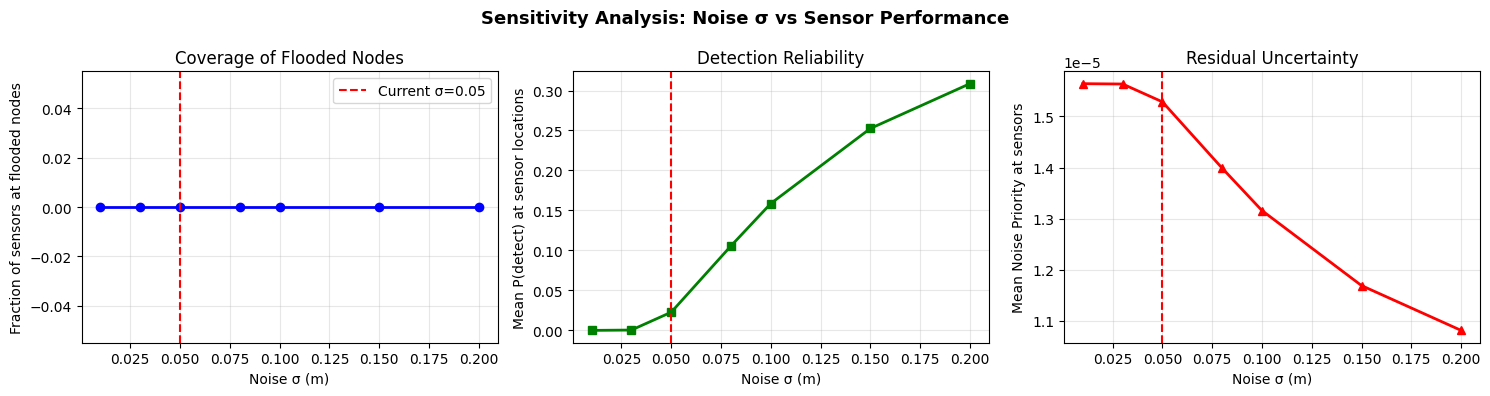

✓ Sensitivity analysis saved to /content/sensitivity_noise.png


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 12 — Sensitivity Analysis: Noise σ vs Sensor Placement
#
#  Varies NOISE_SIGMA from 0.01 to 0.20 m and re-computes:
#  • fraction of sensors at flooded nodes
#  • mean detection probability at placed sensors
#  • mean noise priority at placed sensors
#
#  This tells you: as your sensor hardware gets noisier,
#  how does the optimal placement strategy change?
# ════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

sigma_range  = [0.01, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]
results_sens = []

print('Running sensitivity analysis over noise σ values...')
for sig in sigma_range:
    _det  = sp_norm.cdf((df_flood['max_depth'].values - DEPTH_THRESHOLD) / sig)
    _np   = df_flood['max_depth'].values * (1.0 - _det)
    _np_n = (_np - _np.min()) / (_np.max() - _np.min() + 1e-12)

    # Re-join flood stats to nodes (fast: use existing spatial join)
    # Approximate: rescale the already-joined detect_prob and noise_priority
    # using new sigma, weighted by flood depth
    _detect_at_node  = sp_norm.cdf((df['flood_depth'].values - DEPTH_THRESHOLD) / sig)
    _np_at_node      = df['flood_depth'].values * (1.0 - _detect_at_node)
    _npn_at_node     = (_np_at_node - _np_at_node.min()) / (_np_at_node.max() - _np_at_node.min() + 1e-12)

    # Sensor-level stats using current sensor_df (placement unchanged in sensitivity)
    det_at_sensors  = sp_norm.cdf((sensor_df['flood_depth'].values - DEPTH_THRESHOLD) / sig)
    frac_flooded    = (sensor_df['flood_depth'].values > DEPTH_THRESHOLD).mean()
    mean_det        = det_at_sensors.mean()
    np_at_sens      = sensor_df['flood_depth'].values * (1.0 - det_at_sensors)
    mean_np         = np_at_sens.mean()

    results_sens.append({
        'sigma':         sig,
        'frac_flooded':  frac_flooded,
        'mean_det_prob': mean_det,
        'mean_noise_pri':mean_np,
    })
    print(f'  σ={sig:.2f}m → frac_flooded={frac_flooded:.2f}  '
          f'mean_P(det)={mean_det:.3f}  mean_NP={mean_np:.4f}')

df_sens = pd.DataFrame(results_sens)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sensitivity Analysis: Noise σ vs Sensor Performance', fontsize=13, fontweight='bold')

axes[0].plot(df_sens['sigma'], df_sens['frac_flooded'], 'bo-', linewidth=2)
axes[0].axvline(NOISE_SIGMA, color='red', linestyle='--', label=f'Current σ={NOISE_SIGMA}')
axes[0].set_xlabel('Noise σ (m)'); axes[0].set_ylabel('Fraction of sensors at flooded nodes')
axes[0].set_title('Coverage of Flooded Nodes'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df_sens['sigma'], df_sens['mean_det_prob'], 'gs-', linewidth=2)
axes[1].axvline(NOISE_SIGMA, color='red', linestyle='--')
axes[1].set_xlabel('Noise σ (m)'); axes[1].set_ylabel('Mean P(detect) at sensor locations')
axes[1].set_title('Detection Reliability'); axes[1].grid(alpha=0.3)

axes[2].plot(df_sens['sigma'], df_sens['mean_noise_pri'], 'r^-', linewidth=2)
axes[2].axvline(NOISE_SIGMA, color='red', linestyle='--')
axes[2].set_xlabel('Noise σ (m)'); axes[2].set_ylabel('Mean Noise Priority at sensors')
axes[2].set_title('Residual Uncertainty'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/sensitivity_noise.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Sensitivity analysis saved to /content/sensitivity_noise.png')

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 13 — Sensor Report Table
# ════════════════════════════════════════════════════════════════
from IPython.display import display, HTML

report_cols = [
    'sensor_rank','node_id','y_coord','x_coord','Elev1',
    'importance','flood_depth','detect_prob','noise_priority',
    'low_lying_score','point_type','fclass','gmda_nearest','nearest_building'
]
rep = sensor_df[report_cols].copy()
rep.columns = [
    'Rank','Node ID','Lat','Lon','Elev (m)',
    'Importance','Flood Depth (m)','P(detect)','Noise Priority',
    'Low-Lying','Type','Road Class','GMDA Near','Nearest Bldg'
]
for c in ['Lat','Lon','Elev (m)','Importance','Flood Depth (m)','P(detect)','Noise Priority','Low-Lying']:
    rep[c] = rep[c].round(4)

table_html = rep.to_html(index=False, border=0) \
    .replace('<table ',
             '<table style="border-collapse:collapse;width:100%;font-family:Arial;font-size:12px" ') \
    .replace('<th>',
             '<th style="background:#003d82;color:white;padding:6px 8px;white-space:nowrap">') \
    .replace('<td>',
             '<td style="padding:5px 8px;border-bottom:1px solid #ddd">')
display(HTML(table_html))

# Save to CSV
rep.to_csv('/content/sensor_report_v6.csv', index=False)
print('✓ Report saved to /content/sensor_report_v6.csv')

Rank,Node ID,Lat,Lon,Elev (m),Importance,Flood Depth (m),P(detect),Noise Priority,Low-Lying,Type,Road Class,GMDA Near,Nearest Bldg
1,N012560,28.4566,77.0265,222.6690,0.8813,0.0,0.0228,0.5,0.2672,manhole,secondary,Hero Honda Chowk,commercial
2,N010162,28.4752,77.0083,217.7595,0.8642,0.0,0.0228,0.5,0.4791,manhole,residential,none,commercial
3,N002618,28.4843,77.0949,244.8575,0.8500,0.0,0.0228,0.5,0.0368,manhole,tertiary,Sikanderpur Chowk,residential
4,N001476,28.4765,77.0940,246.2142,0.8500,0.0,0.0228,0.5,0.0900,manhole,tertiary,Sikanderpur Chowk,commercial
5,N019771,28.4741,77.0771,238.6350,0.8500,0.0,0.0228,0.5,0.0495,manhole,residential,Iffco Chowk underpass,residential
6,N024243,28.4172,77.0401,226.2572,0.8500,0.0,0.0228,0.5,0.1675,manhole,secondary,Rajiv Chowk Sohna Road,commercial
7,N015801,28.4622,77.0222,223.4509,0.8500,0.0,0.0228,0.5,0.1811,manhole,residential,Hero Honda Chowk,residential
8,N039522,28.4796,77.0818,243.3212,0.8500,0.0,0.0228,0.5,0.0371,manhole,primary_link,Leg-I Sikanderpur origin,commercial
9,N038947,28.4359,77.0100,219.6200,0.7965,0.0,0.0228,0.5,0.1047,manhole,trunk,Rezangla Chowk,commercial
10,N042471,28.3570,76.8982,258.6260,0.7496,0.0,0.0228,1.0,0.0584,manhole,unclassified,none,residential


✓ Report saved to /content/sensor_report_v6.csv


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 14 — Save All Outputs
# ════════════════════════════════════════════════════════════════
# Map
map_path = '/content/flood_sensor_map_v6.html'
m.save(map_path)
print(f'✓ Map saved: {map_path}')

# Noise model report as text
rpt_path = '/content/noise_model_report.txt'
with open(rpt_path, 'w') as f:
    f.write('=' * 60 + '\n')
    f.write('GURUGRAM FLOOD SENSOR PLACEMENT — v6 NOISE-AWARE\n')
    f.write('=' * 60 + '\n\n')
    f.write(f'Noise std-dev (σ)        : {NOISE_SIGMA} m\n')
    f.write(f'Detection threshold       : {DEPTH_THRESHOLD} m\n')
    f.write(f'Budget                    : ₹{Budget:,.0f}\n')
    f.write(f'Sensors placed            : {len(sensor_nodes)}\n')
    f.write(f'Nodes covered             : {len(covered_nodes):,}/{len(nodes):,}\n')
    f.write(f'At flooded nodes          : {(sensor_df["flood_depth"]>DEPTH_THRESHOLD).sum()}\n')
    f.write(f'Min sensor separation     : {min_sep:.0f} m\n')
    f.write(f'Mean P(detect) at sensors : {sensor_df["detect_prob"].mean():.4f}\n')
    f.write(f'Mean noise priority       : {sensor_df["noise_priority"].mean():.4f}\n\n')
    f.write('SENSOR LOCATIONS\n')
    f.write('-' * 60 + '\n')
    for _, row in sensor_df.iterrows():
        f.write(
            f"#{row['sensor_rank']:>3}  "
            f"({row['y_coord']:.5f}, {row['x_coord']:.5f})  "
            f"imp={row['importance']:.3f}  "
            f"depth={row['flood_depth']:.3f}m  "
            f"P_det={row['detect_prob']:.3f}  "
            f"near={row['gmda_nearest']}\n"
        )
print(f'✓ Noise model report saved: {rpt_path}')

# Download all
try:
    from google.colab import files
    for fpath in [map_path, rpt_path, '/content/sensor_report_v6.csv',
                  '/content/noise_model.png', '/content/sensitivity_noise.png']:
        files.download(fpath)
except Exception:
    print('Download manually from the file browser (not in Colab)')

print('✅ All outputs saved')

✓ Map saved: /content/flood_sensor_map_v6.html
✓ Noise model report saved: /content/noise_model_report.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All outputs saved
